In [2]:
# =====  Use the saved scaler instead of calculating mean/std from all data =====
import numpy as np
import pandas as pd
import joblib
from tensorflow import keras

W = 48
model  = keras.models.load_model(f'best_lstm_w{W}.keras')
X_test = np.load(f'X_test_w{W}.npy')
y_test = np.load(f'y_test_w{W}.npy')

y_pred = model.predict(X_test, verbose=0).flatten()

# Load the scaler fitted on training data only to avoid data leakage
scaler = joblib.load('feature_scaler.pkl')
feature_cols_order = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'AC_POWER']
ac_power_idx = feature_cols_order.index('AC_POWER')
mu = scaler.mean_[ac_power_idx]
sd = scaler.scale_[ac_power_idx]

mse  = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse) * sd
mae  = np.mean(np.abs(y_test - y_pred)) * sd
r2   = 1 - mse / np.var(y_test)

print(f"Test samples : {len(y_test)}")
print(f"MSE (scaled) : {mse:.4f}")
print(f"RMSE         : {rmse:.1f} kW")
print(f"MAE          : {mae:.1f} kW")
print(f"R²           : {r2:.3f}")

Test samples : 10736
MSE (scaled) : 0.2968
RMSE         : 215.5 kW
MAE          : 134.7 kW
R²           : 0.624


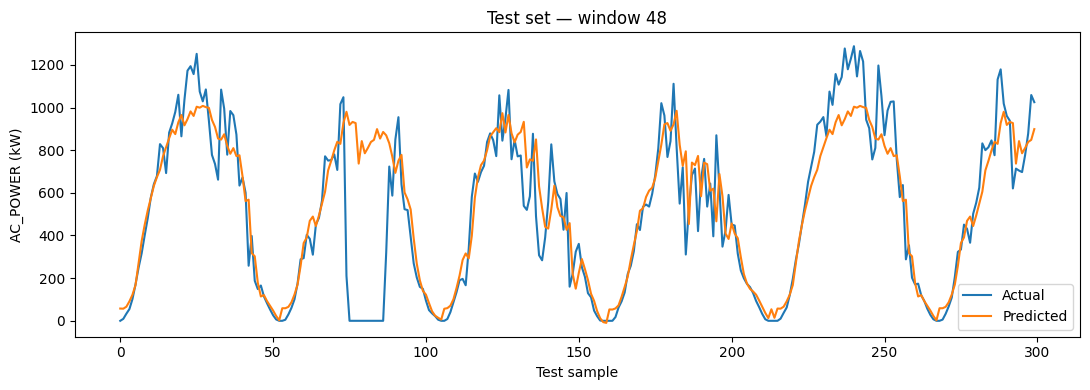

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
from google.colab import files
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 4))
plt.plot(y_test[:300] * sd + mu, label='Actual')
plt.plot(y_pred[:300] * sd + mu, label='Predicted')
plt.ylabel('AC_POWER (kW)'); plt.xlabel('Test sample')
plt.title(f'Test set — window {W}')
plt.legend(); plt.tight_layout()

# Save the plot as an image file, then download it automatically
plt.savefig(f'test_predictions_w{W}.png', dpi=150, bbox_inches='tight')
plt.show()

files.download(f'test_predictions_w{W}.png')
